<a href="https://colab.research.google.com/github/mehek-niwas/openvla-selfie/blob/main/openvla_selfie_planb_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SelfIE for OpenVLA — Gating Experiment + Plan B (external interpreter)

Two experiments only:

1. **Gating experiment.** Can OpenVLA's LM head still produce coherent English once we ban the
   256 action-token IDs? Action tokens are just the tail of the ordinary Llama-2 vocabulary
   (`31744..31999`), so nothing structurally stops text — the question is whether action-only
   fine-tuning destroyed the ability.
2. **Plan B.** Extract OpenVLA hidden states, then interpret them with a *separate* Llama-2-7b
   using SelfIE-style embedding injection. Includes a per-layer representation-drift measurement
   so we know how much to trust the interpretations.

Not in here yet: Plan A (OpenVLA interpreting itself), logit-lens baseline, causal patching, HTML report.

### Structure

The notebook runs in **two phases** so both 7B models never sit on the GPU at once:

| Phase | Model resident | Output |
|---|---|---|
| 1 | OpenVLA-7b (~15 GB) | gating results + `openvla_cache.pt` on disk |
| 2 | Llama-2-7b-chat (~14 GB) | interpretations |

Phase 1 ends by freeing OpenVLA. Re-running Phase 1 cells after that requires reloading the model.
This means a 24 GB L4 is enough; you do not need an A100.

**Runtime > Change runtime type > GPU.**

## may have to switch runtime version in colab to '2026.07', which is python 3.12, since transformers 4.40 seems to not be compatible with python 3.13

In [1]:
!nvidia-smi

Mon Aug 24 21:59:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
!pip install -q "transformers==4.40.1" "tokenizers==0.19.1" "timm==0.9.10" \
               sentencepiece accelerate Pillow datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.


In [3]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# !pip install -q transformers accelerate sentencepiece

In [6]:
import gc, json, torch, numpy as np
import matplotlib.pyplot as plt
from transformers import (AutoModelForVision2Seq, AutoProcessor, AutoModelForCausalLM,
                          AutoTokenizer, LogitsProcessor, LogitsProcessorList)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16

# --- config ---------------------------------------------------------------
VLA_MODEL   = "openvla/openvla-7b"
# NousResearch mirrors are ungated. meta-llama/* needs `huggingface_hub.login()`.
# NOTE: OpenVLA's backbone is Llama-2 7B *base*, not chat. Base is closer in
# representation space; chat follows the "describe this" instruction better.
# Try both — the drift plot in Phase 2 tells you which is safer.
INTERP_MODEL = "NousResearch/Llama-2-7b-chat-hf"
# INTERP_MODEL = "NousResearch/Llama-2-7b-hf"

VOCAB_SIZE   = 32000
N_ACTION_BINS = 256
ACTION_TOK_START = VOCAB_SIZE - N_ACTION_BINS   # 31744; ban everything >= this
CACHE_PATH   = "openvla_cache.pt"

print("device:", DEVICE)
print("action token IDs banned for text generation: >=", ACTION_TOK_START)

device: cuda
action token IDs banned for text generation: >= 31744


---
# Phase 1 — OpenVLA resident

In [7]:
processor = AutoProcessor.from_pretrained(VLA_MODEL, trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    VLA_MODEL, torch_dtype=DTYPE, low_cpu_mem_usage=True, trust_remote_code=True,
    attn_implementation="eager",   # no flash-attn; also required for output_attentions later
).to(DEVICE).eval()

llm     = model.language_model          # LlamaForCausalLM
layers  = llm.model.layers
tok     = processor.tokenizer
N_LAYERS = len(layers)

print(f"layers: {N_LAYERS}  hidden: {llm.config.hidden_size}  "
      f"lm_head out: {llm.lm_head.out_features}  tokenizer vocab: {tok.vocab_size}")
print(f"GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


processor_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openvla/openvla-7b:
- processing_prismatic.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/6.97G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

layers: 32  hidden: 4096  lm_head out: 32064  tokenizer vocab: 32000
GPU: 15.1 GB


## 1. Gating experiment

Everything downstream forks on this result. We call `model.language_model` directly with no image —
the vision tower is bypassed entirely, so this is a pure text forward pass through the fine-tuned
Llama backbone.

Two things are measured:

- **Action-token probability mass** at the first generated position. If this is ~1.0 the model wants
  to emit actions no matter what; if it's low on text prompts, the LM is still "in text mode."
- **Generated text**, with and without the action-token ban, across three prompt formats. OpenVLA
  only ever saw `In: ... \nOut:` during fine-tuning, so the Llama-2 chat format may be badly OOD for it.

In [8]:
class BanActionTokens(LogitsProcessor):
    # Mask the 256 reused action IDs (and the padded-vocab tail above 32000).
    def __init__(self, start=ACTION_TOK_START):
        self.start = start
    def __call__(self, input_ids, scores):
        scores[:, self.start:] = -float("inf")
        return scores

BAN = LogitsProcessorList([BanActionTokens()])

@torch.no_grad()
def text_only(prompt, max_new_tokens=48, ban=True):
    ids = tok(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = llm(input_ids=ids)
    p = out.logits[0, -1].float().softmax(-1)
    action_mass = p[ACTION_TOK_START:].sum().item()
    gen = llm.generate(input_ids=ids, max_new_tokens=max_new_tokens, do_sample=False,
                       pad_token_id=tok.eos_token_id,
                       logits_processor=BAN if ban else None)
    return action_mass, tok.decode(gen[0, ids.shape[1]:], skip_special_tokens=True)

In [9]:
PROMPTS = {
 "llama2-chat":  "[INST] Describe a red apple in one sentence. [/INST]",
 "openvla-fmt":  "In: What action should the robot take to pick up the corn?\nOut:",
 "bare":         "A red apple is",
 "bare-robot":   "The robot arm is currently",
}

for name, p in PROMPTS.items():
    mass, txt_ban = text_only(p, ban=True)
    _,    txt_raw = text_only(p, ban=False, max_new_tokens=16)
    print("=" * 78)
    print(f"[{name}]  action-token prob mass at first step: {mass:.4f}")
    print(f"  prompt      : {p!r}")
    print(f"  UNBANNED    : {txt_raw!r}")
    print(f"  BANNED      : {txt_ban!r}")

[llama2-chat]  action-token prob mass at first step: 0.9774
  prompt      : '[INST] Describe a red apple in one sentence. [/INST]'
  UNBANNED    : '⥤❯食터達忠'
  BANNED      : ''
[openvla-fmt]  action-token prob mass at first step: 1.0000
  prompt      : 'In: What action should the robot take to pick up the corn?\nOut:'
  UNBANNED    : 'ھ菜ŸΈ터ცŸ'
  BANNED      : 'Corn hyp'
[bare]  action-token prob mass at first step: 0.9995
  prompt      : 'A red apple is'
  UNBANNED    : 'ḳŸ甲甲书ḳ菜菜菜達菜ỳ测甲甲甲'
  BANNED      : ''
[bare-robot]  action-token prob mass at first step: 0.9628
  prompt      : 'The robot arm is currently'
  UNBANNED    : 'ŸŸ给给给ˠദˠˠˠˠˠˠˠˠˠ'
  BANNED      : 'ти тиakers兵兵兵兵兵兵兵兵兵embros兵embros兵embros'


**How to read this.**

- Coherent, on-topic text under BANNED → the LM is intact. Plan A (self-interpretation) is live,
  and Plan B's interpretations can be cross-checked against it later.
- Fluent but generic/off-topic text → grammar survived, instruction-following didn't. Plan B is the
  right call; note this explicitly in the writeup.
- Word salad → action SFT wiped the text capability. That is itself a reportable finding, and Plan B
  becomes the only option.

`action-token prob mass` near 1.0 on the `openvla-fmt` prompt is expected and healthy — that's the
model doing its job. What matters is whether it drops on the *text* prompts.

## 2. Extract hidden states

Load a scene, run one multimodal forward pass, and capture the output of every decoder layer via
forward hooks. Hooks rather than `output_hidden_states=True` because they don't depend on the remote
code's return plumbing.

scene: corn_between_cups | instruction: put the yellow corn between the cups


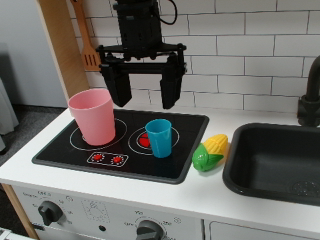

In [10]:
from datasets import load_dataset

ds = load_dataset("Sombit/v3la_eval_database_widowx", split="train", streaming=True)
example = next(iter(ds))
image = example["image"].convert("RGB")

label_names = ["corn_between_cups", "stack_pink_blue_cup"]
scene_instructions = {
    "corn_between_cups":   "put the yellow corn between the cups",
    "stack_pink_blue_cup": "stack the pink cup on the blue cup",
}
scene = label_names[example["label"]]
INSTRUCTION = scene_instructions[scene]

print("scene:", scene, "| instruction:", INSTRUCTION)
image

In [11]:
CAPTURE = {}

def cap_hook(i):
    def f(mod, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        CAPTURE[i] = h.detach()[0].to(torch.float16).cpu()   # (seq, hidden)
    return f

def capture_forward(**fwd):
    CAPTURE.clear()
    handles = [layers[i].register_forward_hook(cap_hook(i)) for i in range(N_LAYERS)]
    try:
        with torch.no_grad():
            out = model(**fwd)
    finally:
        for h in handles: h.remove()
    return out, torch.stack([CAPTURE[i] for i in range(N_LAYERS)])   # (L, seq, hidden)

prompt = f"In: What action should the robot take to {INSTRUCTION}?\nOut:"
inputs = processor(prompt, image).to(DEVICE, dtype=DTYPE)

# OpenVLA's predict_action appends SentencePiece token 29871 to input_ids but does
# NOT extend attention_mask -> off-by-one causal mask under eager attention. Append
# it to BOTH ourselves so generate / capture_forward / predict_action all see an
# identical sequence (otherwise ACTION_H won't match the reported action).
EMPTY_SPACE_ID = 29871
if inputs["input_ids"][0, -1].item() != EMPTY_SPACE_ID:
    pad = torch.full((1, 1), EMPTY_SPACE_ID, dtype=inputs["input_ids"].dtype, device=DEVICE)
    inputs["input_ids"]      = torch.cat([inputs["input_ids"], pad], dim=1)
    inputs["attention_mask"] = torch.cat([inputs["attention_mask"], torch.ones_like(pad)], dim=1)

_, H = capture_forward(**inputs)

n_text  = inputs["input_ids"].shape[1]
n_total = H.shape[1]
n_patch = n_total - n_text
print(f"hidden states: {tuple(H.shape)}  (layers, seq, hidden)")
print(f"text tokens: {n_text}   patch tokens: {n_patch}   total: {n_total}")
assert n_patch == 256, f"expected 256 patch tokens, got {n_patch} — check the layout assumption"

# Prismatic splices projected patches in AFTER BOS: [BOS][256 patches][text...]
PATCH_SLICE = slice(1, 1 + n_patch)
DECISION_POS = n_total - 1          # last prompt token (the appended 29871) -> action dim 0
print("token layout confirmed:",
      [tok.decode([t]) for t in inputs['input_ids'][0, :3].tolist()], "... + patches + text")

hidden states: (32, 279, 4096)  (layers, seq, hidden)
text tokens: 23   patch tokens: 256   total: 279
token layout confirmed: ['<s>', 'In', ':'] ... + patches + text


In [12]:
# --- states at the 7 action positions ------------------------------------
# Generate the action, then teacher-force it back in as one full sequence.
# Position -7 is the last prompt token (produces action dim 0); -1 produces dim 6.
with torch.no_grad():
    gen = model.generate(**inputs, max_new_tokens=7, do_sample=False)
action_ids = gen[0, -7:]
bin_ids = [VOCAB_SIZE - t - 1 for t in action_ids.tolist()]
print("action token ids:", action_ids.tolist(), "-> bins:", bin_ids)

full_ids = torch.cat([inputs["input_ids"], action_ids[None, :6]], dim=1)
_, H_act = capture_forward(input_ids=full_ids,
                           attention_mask=torch.ones_like(full_ids),
                           pixel_values=inputs["pixel_values"])
ACTION_H = H_act[:, -7:, :].clone()          # (L, 7, hidden)
print("action-position states:", tuple(ACTION_H.shape))

action = model.predict_action(**inputs, unnorm_key="bridge_orig", do_sample=False)
ACTION_LABELS = ["dx","dy","dz","droll","dpitch","dyaw","gripper"]
print({k: round(float(v), 4) for k, v in zip(ACTION_LABELS, action)})

action token ids: [31875, 31872, 31927, 31876, 31822, 31871, 31744] -> bins: [124, 127, 72, 123, 177, 128, 255]
action-position states: (32, 7, 4096)
{'dx': -0.0009, 'dy': -0.0004, 'dz': -0.0073, 'droll': -0.0021, 'dpitch': 0.026, 'dyaw': -0.0001, 'gripper': 0.9961}


In [13]:
# --- drift probe: same plain text through both models, compared in Phase 2 ---
DRIFT_TEXT = ("The robot arm moved slowly toward the yellow corn on the table. "
              "A blue cup sat beside a pink cup near the edge of the tray.")
probe_ids = tok(DRIFT_TEXT, return_tensors="pt").input_ids.to(DEVICE)
CAPTURE.clear()
handles = [layers[i].register_forward_hook(cap_hook(i)) for i in range(N_LAYERS)]
try:
    with torch.no_grad(): llm(input_ids=probe_ids)
finally:
    for h in handles: h.remove()
H_probe = torch.stack([CAPTURE[i] for i in range(N_LAYERS)])

# a few instruction-token positions, for the "does it recover the word" control
text_start = 1 + n_patch
text_toks  = [(i, tok.decode([t])) for i, t in enumerate(inputs["input_ids"][0].tolist())]

torch.save({
    "H_patch":      H[:, PATCH_SLICE, :].clone(),      # (L, 256, hidden) fp16
    "H_text":       H[:, text_start:, :].clone(),      # (L, n_text-1, hidden)
    "H_decision":   H[:, DECISION_POS, :].clone(),     # (L, hidden)
    "H_action":     ACTION_H,                          # (L, 7, hidden)
    "H_probe":      H_probe,                           # (L, probe_len, hidden)
    "probe_text":   DRIFT_TEXT,
    "text_tokens":  text_toks,
    "instruction":  INSTRUCTION,
    "action":       [float(a) for a in action],
    "n_layers":     N_LAYERS,
}, CACHE_PATH)
image.save("scene.png")
print("cached ->", CACHE_PATH)

cached -> openvla_cache.pt


In [14]:
# --- free OpenVLA --------------------------------------------------------
del model, llm, layers, processor, tok, H, H_act, H_probe, ACTION_H, inputs
gc.collect(); torch.cuda.empty_cache()
print(f"GPU after free: {torch.cuda.memory_allocated()/1e9:.1f} GB")

GPU after free: 0.2 GB


---
# Phase 2 — Llama-2 interpreter resident (Plan B)

OpenVLA is gone; everything from here reads `openvla_cache.pt`.

In [15]:
itok = AutoTokenizer.from_pretrained(INTERP_MODEL)
imodel = AutoModelForCausalLM.from_pretrained(
    INTERP_MODEL, torch_dtype=DTYPE, low_cpu_mem_usage=True,
    attn_implementation="eager",
).to(DEVICE).eval()
ilayers = imodel.model.layers

C = torch.load(CACHE_PATH)
assert len(ilayers) == C["n_layers"], "layer count mismatch between backbone and interpreter"
print(f"interpreter: {INTERP_MODEL} | layers: {len(ilayers)}")
print(f"GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB")

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

interpreter: NousResearch/Llama-2-7b-chat-hf | layers: 32
GPU: 13.7 GB


## 3. Representation drift

OpenVLA is a full fine-tune of Llama-2 7B, so its residual stream is the *same basis, drifted*.
Plan B is only as trustworthy as that drift is small. Run identical text through both and compare
per-layer.

This cell also collects the interpreter's median hidden-state norm per layer, used for optional
norm-matching when injecting.

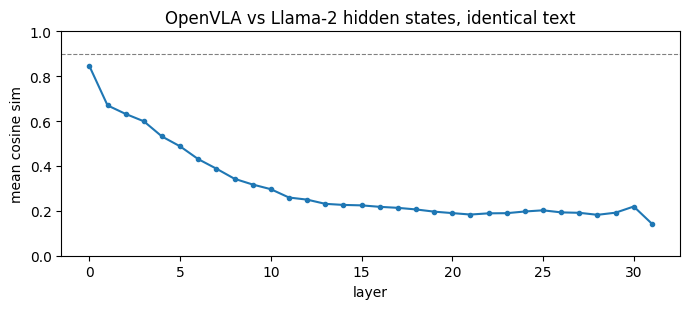

cos sim by layer: [0.845, 0.67, 0.632, 0.599, 0.531, 0.487, 0.43, 0.388, 0.343, 0.317, 0.296, 0.259, 0.25, 0.231, 0.226, 0.224, 0.218, 0.213, 0.206, 0.196, 0.19, 0.184, 0.189, 0.19, 0.197, 0.202, 0.193, 0.191, 0.182, 0.192, 0.219, 0.143]

>0.9 across most layers -> Plan B interpretations are reasonably trustworthy.
Sharp drop in later layers is normal (that's where action-specific structure lives).


In [16]:
probe_ids = itok(C["probe_text"], return_tensors="pt").input_ids.to(DEVICE)
IC = {}
def icap(i):
    def f(m, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        IC[i] = h.detach()[0].float().cpu()
    return f
handles = [ilayers[i].register_forward_hook(icap(i)) for i in range(len(ilayers))]
try:
    with torch.no_grad(): imodel(input_ids=probe_ids)
finally:
    for h in handles: h.remove()
H_llama = torch.stack([IC[i] for i in range(len(ilayers))])
H_vla   = C["H_probe"].float()

assert H_llama.shape == H_vla.shape, (H_llama.shape, H_vla.shape)
cos = torch.nn.functional.cosine_similarity(H_vla, H_llama, dim=-1).mean(dim=1)   # per layer
LLAMA_NORMS = H_llama.norm(dim=-1).median(dim=1).values                            # per layer

plt.figure(figsize=(7,3.2))
plt.plot(cos.numpy(), marker="o", ms=3)
plt.axhline(0.9, ls="--", c="grey", lw=0.8)
plt.xlabel("layer"); plt.ylabel("mean cosine sim"); plt.ylim(0,1)
plt.title("OpenVLA vs Llama-2 hidden states, identical text")
plt.tight_layout(); plt.show()

print("cos sim by layer:", [round(float(v),3) for v in cos])
print("\n>0.9 across most layers -> Plan B interpretations are reasonably trustworthy.")
print("Sharp drop in later layers is normal (that's where action-specific structure lives).")

## 4. SelfIE injection (paper-exact config)

From SelfIE §4.1: interpretation prompt `[INST] [X] [/INST] Sure, I'll summarize your message:`,
with `[X]` repeated **five times**, all five replaced by the **same** embedding, injected at
layer **k = 3**. Fig. 11 ablates k and finds k < 20 works, degrading later because the injected
information can no longer propagate to the last token.

Three details that silently break this:

- **Inject early.** Source layer and target layer are decoupled. Injecting at the source layer
  (e.g. 16) gives the model 16 layers to conclude the placeholders are literal underscores before
  your vector ever lands — which produces confident nonsense about character sequences.
- **The hook must fire only on the prefill pass.** During KV-cached decoding `seq_len == 1`; the
  placeholder positions are already cached, so re-writing would clobber the generation.
- **Count slots, not calls to `encode`.** `encode("_")` returns the SentencePiece `▁` marker *plus*
  `_`, so `[ph] * 5` silently yields 10 positions. Use a single token id.

Caveat: the paper's numbers are on LLaMA-2-**70B**-Chat. It reports 27.17% of 7B interpretations
fail to follow the instruction vs 3.84% at 70B, so expect noisier output here.

In [17]:
# --- paper defaults ------------------------------------------------------
N_PLACEHOLDERS = 5      # paper repeats [X] five times
INJECT_LAYER   = 3      # paper's k -- NOT the source layer
NORM_MATCH     = False  # paper does none (self-injection). Cross-model here, so
                        # try False first; flip on only if output is degenerate.

# Single token id. encode("_") returns [SP-marker, "_"], so take the last piece.
PH_ID = itok.encode("_", add_special_tokens=False)[-1]

def build_interp_prompt(n_slots=N_PLACEHOLDERS):
    pre   = itok.encode("[INST] ", add_special_tokens=True)          # includes BOS
    post  = itok.encode(" [/INST] Sure, I'll summarize your message:",
                        add_special_tokens=False)
    ids   = pre + [PH_ID] * n_slots + post
    slots = list(range(len(pre), len(pre) + n_slots))
    return ids, slots

INTERP_IDS, SLOTS = build_interp_prompt()
assert len(SLOTS) == N_PLACEHOLDERS
print(f"interp prompt: {len(INTERP_IDS)} tokens, {len(SLOTS)} slots at {SLOTS}")
print(repr(itok.decode(INTERP_IDS)))

def make_inject_hook(vecs, slots):
    # vecs: (B, hidden) - one vector per batch item, broadcast across all slots.
    def f(mod, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        if h.shape[1] <= 1:            # decode step, KV cache active -> skip
            return out
        h[:, slots, :] = vecs[:, None, :].to(h.dtype)
        return out
    return f

@torch.no_grad()
def interpret(vecs, source_layer=None, k=INJECT_LAYER, max_new_tokens=24, bs=8):
    # vecs: (N, hidden) OpenVLA hidden states. Injected at layer k (default 3).
    # source_layer only picks the norm-match target; it does NOT set where the
    # vector is injected.
    if vecs.dim() == 1:
        vecs = vecs[None]
    v = vecs.float()
    if NORM_MATCH:
        tgt = LLAMA_NORMS[k if source_layer is None else source_layer]
        v = v / v.norm(dim=-1, keepdim=True).clamp_min(1e-6) * tgt
    outs = []
    for i in range(0, len(v), bs):
        b   = v[i:i+bs].to(DEVICE, dtype=DTYPE)
        ids = torch.tensor([INTERP_IDS] * len(b), device=DEVICE)
        h   = ilayers[k - 1].register_forward_hook(make_inject_hook(b, SLOTS))
        try:
            g = imodel.generate(input_ids=ids, max_new_tokens=max_new_tokens,
                                do_sample=False, pad_token_id=itok.eos_token_id)
        finally:
            h.remove()
        outs += [s.strip() for s in itok.batch_decode(g[:, len(INTERP_IDS):],
                                                      skip_special_tokens=True)]
    return outs

interp prompt: 25 tokens, 5 slots at [5, 6, 7, 8, 9]
"<s> [INST]  _ _ _ _ _  [/INST] Sure, I'll summarize your message:"


## 5. Controls — run these before believing anything

- **Text-token control**: SelfIE reliably recovers content from ordinary text tokens. If injecting an
  instruction-token state doesn't produce something related to that word, stop here.
- **Random-vector control**: if random noise yields equally plausible sentences, you're reading the
  interpreter's prior, not OpenVLA's content. (Scaled to match real state norms, so this is a fair
  comparison rather than a trivially-broken input.)

Interpreting this control is the whole point of having validated the harness on vanilla Llama first:
if the vanilla Everest notebook recovers words but **this** doesn't, that isolates the finding to
OpenVLA's representations having drifted out of Llama's basis — a result, not a bug. Cross-check
against the drift plot in section 3.

In [18]:
LAYER = 16   # SOURCE layer for the states; injection is always at k=INJECT_LAYER

toks = C["text_tokens"]
pick = [i for i, (idx, s) in enumerate(toks) if s.strip() and not s.startswith("<")][-8:]
vecs = C["H_text"][LAYER][pick]

print(f"--- text-token control (source L{LAYER}, injected at k={INJECT_LAYER}) ---")
for j, out in zip(pick, interpret(vecs, source_layer=LAYER)):
    print(f"  token {toks[j][1]!r:>14} -> {out}")

print(f"\n--- random-vector control ---")
rand = torch.randn(4, vecs.shape[-1]) * vecs.float().norm(dim=-1).mean() / (vecs.shape[-1] ** 0.5)
for out in interpret(rand, source_layer=LAYER):
    print("  random ->", out)

--- text-token control (source L16, injected at k=3) ---


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:497: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


  token         'corn' -> * Between the ages of 15 and 18, the number of hours spent on social media per
  token      'between' -> You have a list of 10 items, and you want to know if there are any duplicates in the
  token          'the' -> You asked me if I could summarize your message, and I'm happy to help! Here's
  token           'cu' -> You've provided a list of 10 popular music genres, along with their corresponding abbreviations
  token           'ps' -> You are asking for a summary of a message that you did not provide. Could you please provide the message you
  token            '?' -> You have asked me to summarize your message, but there is no message to summarize. Please provide a
  token          'Out' -> You have a question that starts with "What is the" and ends with "?"

Unfortunately,
  token            ':' -> You are asking for a summary of a message that contains the following text:

"I have a question

--- random-vector control ---
  random -> Egi Fro Undank Fort E

## 6. The decision token, across layers

The state at the final prompt token — the model's commitment right before it emits action dim 0.
Sweeping layers shows the representation forming.

In [19]:
SWEEP = list(range(0, C["n_layers"], 4)) + [C["n_layers"] - 1]
print(f"instruction: {C['instruction']!r}   (injecting at k={INJECT_LAYER})\n")
for L in SWEEP:
    out = interpret(C["H_decision"][L], source_layer=L)[0]
    print(f"  source L{L:>2} -> {out}")

instruction: 'put the yellow corn between the cups'   (injecting at k=3)

  source L 0 -> You have a question about how to use the `INST` command in Linux. Specifically, you want to know
  source L 4 -> "I'm not sure what you want me to do. Please provide more context or clarify your request."
  source L 8 -> You have 5 messages and you want me to summarize them. However, there are no messages in your
  source L12 -> You have 1000000000000000000
  source L16 -> You are asking for a summary of a message that is not provided in the input. Could you please provide the
  source L20 -> You want to know how to get a girl to like you, right? Here are some tips that might help
  source L24 -> You want to know how to make a good first impression on someone you just met. Here are some tips:
  source L28 -> You are asking for a summary of a message that is not provided in the input. Could you please provide the
  source L31 -> ### Description

This is a virtual office that provides a range of ser

## 7. The 7 action positions

Each position is the state that produced one action dimension. The question worth asking:
does the state before the gripper token contain anything like "grasp" or "close"?

In [20]:
ACTION_LABELS = ["dx","dy","dz","droll","dpitch","dyaw","gripper"]
for L in [12, 16, 20]:
    print(f"===== source layer {L} =====")
    outs = interpret(C["H_action"][L], source_layer=L)
    for lbl, val, out in zip(ACTION_LABELS, C["action"], outs):
        print(f"  {lbl:>8} = {val:+.3f}  -> {out}")
    print()

===== source layer 12 =====
        dx = -0.001  -> You have 1000000000000000000
        dy = -0.000  -> You want to know how to make a list of 10 items, but you don't want to
        dz = -0.007  -> You are asking for a summary of a message that is not provided in the chat. Could you please provide more
     droll = -0.002  -> The acronym "TH" could refer to several things, but the most common interpretation is "The Hand
    dpitch = +0.026  -> You are asking for a summary of a message that you did not write. Could you please provide more context or
      dyaw = -0.000  -> You want me to list 10 things that are true about the country of [NS]. Here is the
   gripper = +0.996  -> You are saying that the statement "The quick brown fox jumps over the lazy dog" is a meaning

===== source layer 16 =====
        dx = -0.001  -> You are asking for a summary of a message that is not provided in the input. Could you please provide the
        dy = -0.000  -> You're right, [INST] is a powerful t

## 8. Patch grid

The 256 patch tokens form a 16×16 grid in direct spatial correspondence with the image. Interpreting
all 256 is slow, so this **samples** 16 individual patches on a regular stride.

Deliberately *not* mean-pooling 4×4 blocks. LLM hidden states carry a large shared component, so
averaging amplifies what patches have in common and cancels what distinguishes them — then every
cell interprets identically. The `pairwise cos` figure below tells you whether that risk is real
here: if sampled patches are already ~0.99 similar to each other, subtract the mean before
interpreting (`P - P.mean(0)`).

sampled patches: mean pairwise cos = 0.372  (>0.99 -> subtract Pn.mean(0) before interpreting)


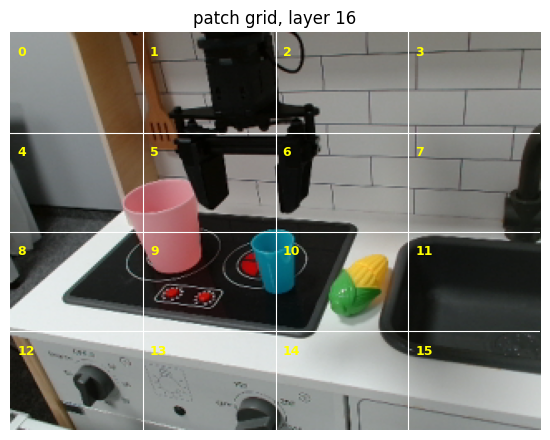

  [ 0] patch(r 2,c 2) -> "I don't understand why I'm here. I don't remember anything before waking up
  [ 1] patch(r 2,c 6) -> You are asking for help in understanding why you are seeing a blank page when you try to access a website.
  [ 2] patch(r 2,c10) -> You have 5 messages and you want me to summarize them. However, I'm a large language
  [ 3] patch(r 2,c14) -> You have 5 messages and you want me to summarize them. However, I'm a large language
  [ 4] patch(r 6,c 2) -> "I don't understand why I'm here. I don't remember anything before waking up
  [ 5] patch(r 6,c 6) -> You want to know how to make 0 (zero) as a number in mathematics.

In mathematics
  [ 6] patch(r 6,c10) -> You have no message. Please provide a message or question, and I'll be happy to help.
  [ 7] patch(r 6,c14) -> "I don't understand why I'm here. I don't remember anything before waking up
  [ 8] patch(r10,c 2) -> "I have no idea what you're trying to say. Please provide more context or clarify your message."
  

In [21]:
GRID    = 4    # 4 -> 16 sampled patches; 8 -> 64; 16 -> all 256 (slow)
LAYER_P = 16

P = C["H_patch"][LAYER_P].float().reshape(16, 16, -1)      # (16,16,hidden)
step = 16 // GRID
rows = cols = list(range(step // 2, 16, step))             # regular stride, no pooling
sel = torch.stack([P[r, c] for r in rows for c in cols])   # (GRID*GRID, hidden)

Pn = P.reshape(256, -1)
Sn = sel / sel.norm(dim=-1, keepdim=True)
off = (Sn @ Sn.T)[~torch.eye(len(sel), dtype=bool)]
print(f"sampled patches: mean pairwise cos = {off.mean():.3f}  "
      f"(>0.99 -> subtract Pn.mean(0) before interpreting)")

outs = interpret(sel, source_layer=LAYER_P)

img = plt.imread("scene.png")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(img)
h, w = img.shape[:2]
for i in range(1, GRID):
    ax.axhline(i * h / GRID, c="w", lw=0.8); ax.axvline(i * w / GRID, c="w", lw=0.8)
for i in range(GRID):
    for j in range(GRID):
        ax.text(j * w / GRID + 4, i * h / GRID + 14, f"{i*GRID+j}",
                c="yellow", fontsize=9, weight="bold")
ax.axis("off"); ax.set_title(f"patch grid, layer {LAYER_P}"); plt.tight_layout(); plt.show()

for n, out in enumerate(outs):
    print(f"  [{n:>2}] patch(r{rows[n//GRID]:>2},c{cols[n%GRID]:>2}) -> {out}")

## 9. Instruction swap — does the interpretation track the task?

The most important validity check for the patch interpretations. If swapping the instruction while
holding the image fixed doesn't change what the patches say, you're reading the vision encoder, not
the VLA. Requires reloading OpenVLA, so it's left as the obvious next cell to write rather than run
inline here.

### Next steps

- Instruction-swap comparison (rerun Phase 1 with a second instruction, diff the interpretations)
- Logit-lens baseline — ~15 lines, no injection, catches broken hooks
- Plan A, if the gating experiment came back clean
- Per-layer linear map `W` fit on the drift probe, if cosine similarity turned out low
- Causal patching: splice a patch state from image A into image B, check the action moves the way
  the interpretation predicts
- HTML report